# Парсинг драгметаллов

Для драг. металлов и валюты:
- engine: `currency`
- market: `selt`
- board: `cets`

Тикеры драгметаллов и валюты можно найти здесь: `https://iss.moex.com/iss/engines/currency/markets/selt/boards/CETS/securities`




In [ ]:
from enum import Enum, IntEnum
from aiomoex import get_board_candles
import asyncio
import aiohttp
from datetime import datetime, timedelta, date
import pandas as pd


class Engines(Enum):
    """https://iss.moex.com/iss/engines"""

    STOCK = "stock"  # Фондовый рынок и рынок депозитов
    STATE = "state"  # Рынок ГЦБ (размещение)
    CURRENCY = "currency"  # Валютный рынок
    FUTURES = "futures"  # Срочный рынок
    COMMODITY = "commodity"  # Товарный рынок
    INTERVENTIONS = "interventions"  # Товарные интервенции
    OFFBOARD = "offboard"  # ОТС-система
    AGR = "agro"  # Агро
    OTC = "otc"  # ОТС с ЦК
    QUOTES = "quotes"  # Квоты
    MONEY = "money"  # Денежный рынок


class Markets(Enum):
    """https://iss.moex.com/iss/engines/<engine>/markets"""

    # engine=currency
    OTCINDICES = "otcindices"  # Внебиржевые индексы
    SELT = "selt"  # Биржевые сделки с ЦК
    FUTURES = "futures"  # Поставочные фьючерсы
    INDEX = "index"  # Валютный фиксинг
    OTC = "otc"  # Внебиржевой

    # engine=futures
    FORTS = "forts"  # Фьючерсы
    OPTIONS = "options"  # Опционы
    FORTSIQS = "fortsiqs"  # Фьючерсы IQS
    OPTIONSIQS = "optionsiqs"  # Опционы IQS
    MAIN = "main"  # Срочные инструменты


class Boards(Enum):
    """https://iss.moex.com/iss/engines/<engine>/markets/<market>/boards"""

    # engine=currency, market=selt
    TQBR = "TQBR"  # Фондовый рынок
    AUCB = "AUCB"  # Аукцион ЦБР - адрес.
    CETS = "CETS"  # Системные сделки - безадрес.
    CNGD = "CNGD"  # Внесистемные сделки- адрес.
    CURR = "CURR"  # Дневная сессия
    FIXN = "FIXN"  # Фиксинг внесистемный- адрес.
    FIXS = "FIXS"  # Фиксинг системный - безадрес.
    LICU = "LICU"  # Внесистемные сделки урегулирования - безадрес.
    SDBP = "SDBP"  # Крупные сделки - безадрес.
    SPEC = "SPEC"  # Поставка - безадресные
    WAPN = "WAPN"  # Внесистемные средневзвешенные - адрес.
    WAPS = "WAPS"  # Системные средневзвешенные - безадрес.

    # engine=futures, market=forts
    RFUD = "RFUD"  # Фьючерсы


class IntervalEnum(IntEnum):
    MINUTE = 1
    TEN_MINUTES = 10
    HOUR = 60
    DAY = 24
    WEEK = 7
    MONTH = 31


# объявим аннотацию для удобства
StockData = list[dict[str, str | int | float]]


async def fetch_ticker_data(
    session: aiohttp.ClientSession,
    ticker: str,
    interval: IntervalEnum,
    start_date: str,
    end_date: str,
    board: Boards,
    engine: Engines,
    market: Markets,
) -> dict[str, pd.DataFrame]:
    """Функция получает данные о торгах по заданному тикеру с *start_date* по *end_date* с интервалом *interval*, возвращая словарь, где ключом является тикер, а значением - данные

    Args:
        session (aiohttp.ClientSession): aiottp сессия для отпаравки запросов
        ticker (str): Имя тикера
        interval (IntervalEnum): Одно из доступных значений для интервала времени
        start_date (str): Начальная дата в формате yyyy-mm-dd
        end_date (str): Конечная дата в формате yyyy-mm-dd

    Returns:
        dict[str, list[dict[str, str | int | float]]]: Словарь, где ключ - тикер, а значение - данные, например {'SBER': sber_data}
    """
    try:
        # получаем данные по переданному тикеру за указанный период
        res = await get_board_candles(
            session,
            ticker,
            interval,
            start_date,
            end_date,
            board=board.value,
            market=market.value,
            engine=engine.value,
        )
        if res:
            df = pd.DataFrame(res)

            if "end" in df.columns:
                df = df.drop("end", axis=1)

            df["begin"] = pd.to_datetime(df["begin"])

            if interval in [24, 7, 31]:
                df["begin"] = df["begin"].dt.normalize()

            if "begin" in df.columns:
                cols = ["begin"] + [col for col in df.columns if col != "begin"]
                df = df[cols]

            df["ticker"] = ticker
            return {ticker: df}
        else:
            return {ticker: pd.DataFrame()}
    except Exception as e:
        print(f"Ошибка парсинга. Не удалось получить данные для {ticker}, {e}")
        return {ticker: pd.DataFrame()}


async def get_moex_data(
    tickers: list[str],
    start_date: datetime,
    end_date: datetime = datetime.now(),
    interval: IntervalEnum = IntervalEnum.DAY,
    engine: Engines = Engines.CURRENCY,
    market: Markets = Markets.SELT,
    board: Boards = Boards.CETS,
) -> dict[str, pd.DataFrame]:
    if interval not in IntervalEnum:
        raise ValueError(f"Неверный интервал. Допустимые значения: {IntervalEnum}")

    end_date_formatted = end_date.strftime("%Y-%m-%d %H:%M:%S")
    start_date_formatted = start_date.strftime("%Y-%m-%d %H:%M:%S")

    # Увеличиваем таймауты для MOEX API
    timeout = aiohttp.ClientTimeout(
        connect=30,  # время подключения
        sock_read=60,  # время чтения данных
        total=120,  # общий таймаут
    )

    async with aiohttp.ClientSession(timeout=timeout) as session:
        # собираем корутины в список
        coros = [
            fetch_ticker_data(
                session,
                ticker,
                interval,
                start_date_formatted,
                end_date_formatted,
                board,
                engine,
                market,
            )
            for ticker in tickers
        ]
        # 'собираем' результаты корутин - непосредственно парсинг
        stock_data = await asyncio.gather(*coros)

    # разворачиваем список словарей в один словарь, например: [ {'SBER': sber_data}, {'GAZP': gazp_data} ] -> { 'SBER': sber_data, 'GAZP': gazp_data }
    stock_data = {
        ticker: data for element in stock_data for ticker, data in element.items()
    }
    return stock_data

In [4]:
from dataclasses import dataclass


@dataclass
class Asset:
    """Общий класс для активов с нужными параметрами для получения данных с MOEX"""

    engine: Engines
    market: Markets
    board: Boards
    ticker: str

    async def get_candles(
        self, start_date: datetime, end_date: datetime, interval: IntervalEnum
    ) -> pd.DataFrame:
        data = await get_moex_data(
            tickers=[self.ticker],
            start_date=start_date,
            end_date=end_date,
            interval=interval,
            engine=self.engine,
            market=self.market,
            board=self.board,
        )
        return data[self.ticker]

    def __str__(self) -> str:
        return f"Актив: {self.ticker}. Параметры MOEX: engine={self.engine}, market={self.market}, board={self.board}"


In [5]:
gold = Asset(
    engine=Engines.CURRENCY,
    market=Markets.SELT,
    board=Boards.CETS,
    ticker="GLDRUB_TOM",
)
display(
    await gold.get_candles(
        start_date=datetime.now() - timedelta(days=180),
        end_date=datetime.now(),
        interval=IntervalEnum.DAY,
    )
)

,begin,open,close,high,low,value,volume,ticker
0,2025-05-21,8550.3,8479.9,8571.0,8431.2,5.207544e+09,613749,GLDRUB_TOM
1,2025-05-22,8501.0,8459.9,8514.9,8358.6,2.381779e+09,281855,GLDRUB_TOM
2,2025-05-23,8503.2,8529.6,8561.0,8465.0,2.842357e+09,334234,GLDRUB_TOM
3,2025-05-26,8485.1,8513.1,8520.0,8475.0,1.816013e+09,213630,GLDRUB_TOM
4,2025-05-27,8484.6,8407.0,8484.6,8397.3,2.340755e+09,277808,GLDRUB_TOM
...,...,...,...,...,...,...,...,...
122,2025-11-10,10531.5,10632.1,10682.3,10531.5,3.197471e+09,301802,GLDRUB_TOM
123,2025-11-11,10749.0,10666.8,10808.9,10619.4,3.562875e+09,331186,GLDRUB_TOM
124,2025-11-12,10680.4,10840.0,10850.0,10666.7,5.457155e+09,509262,GLDRUB_TOM
125,2025-11-13,10860.2,10887.3,10964.8,10825.6,7.133326e+09,654457,GLDRUB_TOM


In [6]:
silver = Asset(
    engine=Engines.CURRENCY,
    market=Markets.SELT,
    board=Boards.CETS,
    ticker="SLVRUB_TOM",
)
display(
    await silver.get_candles(
        start_date=datetime.now() - timedelta(days=180),
        end_date=datetime.now(),
        interval=IntervalEnum.DAY,
    )
)

,begin,open,close,high,low,value,volume,ticker
0,2025-05-21,119.70,118.70,120.84,118.24,9921635,83200,SLVRUB_TOM
1,2025-05-22,118.69,118.60,119.49,118.02,10536317,88800,SLVRUB_TOM
2,2025-05-23,118.70,117.50,118.96,117.50,14332957,121300,SLVRUB_TOM
3,2025-05-26,117.98,116.59,118.00,115.11,26320229,226000,SLVRUB_TOM
4,2025-05-27,116.56,115.47,116.56,114.56,15062292,130400,SLVRUB_TOM
...,...,...,...,...,...,...,...,...
122,2025-11-10,147.00,147.92,150.10,144.90,193005668,1316100,SLVRUB_TOM
123,2025-11-11,149.04,144.70,151.30,143.00,224315484,1518400,SLVRUB_TOM
124,2025-11-12,147.00,150.16,150.85,145.10,219478115,1477700,SLVRUB_TOM
125,2025-11-13,155.28,150.64,155.28,148.05,375073651,2454400,SLVRUB_TOM


In [7]:
platinum = Asset(
    engine=Engines.CURRENCY,
    market=Markets.SELT,
    board=Boards.CETS,
    ticker="PLTRUB_TOM",
)
display(
    await platinum.get_candles(
        start_date=datetime.now() - timedelta(days=180),
        end_date=datetime.now(),
        interval=IntervalEnum.DAY,
    )
)

,begin,open,close,high,low,value,volume,ticker
0,2025-05-21,2696.99,2707.00,2729.98,2651.77,20042414.31,7451,PLTRUB_TOM
1,2025-05-22,2717.00,2715.00,2750.00,2667.13,12966501.50,4807,PLTRUB_TOM
2,2025-05-23,2744.76,2790.00,2799.00,2735.00,24801178.84,8972,PLTRUB_TOM
3,2025-05-26,2760.00,2783.01,2809.99,2760.00,14199624.62,5092,PLTRUB_TOM
4,2025-05-27,2791.00,2769.98,2796.22,2715.00,7295471.71,2626,PLTRUB_TOM
...,...,...,...,...,...,...,...,...
122,2025-11-10,4100.00,4128.74,4155.68,4070.00,42308775.71,10286,PLTRUB_TOM
123,2025-11-11,4132.11,4128.75,4220.00,4128.75,28143741.86,6718,PLTRUB_TOM
124,2025-11-12,4187.90,4200.02,4274.99,4140.01,15301063.04,3647,PLTRUB_TOM
125,2025-11-13,4269.00,4217.15,4293.36,4178.69,13874135.41,3256,PLTRUB_TOM


In [8]:
palladium = Asset(
    engine=Engines.CURRENCY,
    market=Markets.SELT,
    board=Boards.CETS,
    ticker="PLDRUB_TOM",
)
display(
    await palladium.get_candles(
        start_date=datetime.now() - timedelta(days=180),
        end_date=datetime.now(),
        interval=IntervalEnum.DAY,
    )
)

,begin,open,close,high,low,value,volume,ticker
0,2025-05-21,2568.00,2573.00,2600.00,2540.00,9861511.93,3829,PLDRUB_TOM
1,2025-05-22,2571.00,2541.01,2602.42,2532.10,7688786.93,3011,PLDRUB_TOM
2,2025-05-23,2577.00,2570.00,2596.47,2551.02,7369419.59,2861,PLDRUB_TOM
3,2025-05-26,2569.00,2540.00,2569.00,2513.14,8778346.34,3469,PLDRUB_TOM
4,2025-05-27,2545.00,2538.98,2550.00,2503.88,5622176.62,2218,PLDRUB_TOM
...,...,...,...,...,...,...,...,...
122,2025-11-10,3628.98,3616.89,3629.98,3533.65,33488567.34,9370,PLDRUB_TOM
123,2025-11-11,3620.00,3610.00,3669.97,3575.01,32309906.95,8893,PLDRUB_TOM
124,2025-11-12,3616.89,3685.49,3689.96,3601.21,23149433.09,6321,PLDRUB_TOM
125,2025-11-13,3689.98,3634.99,3755.00,3609.94,22029070.44,5954,PLDRUB_TOM


# Нефть

In [9]:
# MOEX

# На MOEX нет индекса цены нефти, есть только фьючерсы.
# Список фьючерсов можно глянуть здесь:
# https://iss.moex.com/iss/engines/futures/markets/forts/boards/rfud/securities

BRENT_FUTURES = [
    "BRF6",  # 1.26
    "BRG6",  # 2.26
    "BRZ5",  # 12.25
]

for future_name in BRENT_FUTURES:
    print("Future:", future_name)
    brent_future = Asset(
        engine=Engines.FUTURES,
        market=Markets.FORTS,
        board=Boards.RFUD,
        ticker=future_name,
    )
    display(
        await brent_future.get_candles(
            start_date=datetime.now() - timedelta(days=180),
            end_date=datetime.now(),
            interval=IntervalEnum.DAY,
        )
    )


Future: BRF6


,begin,open,close,high,low,value,volume,ticker
0,2025-05-22,65.95,65.80,65.95,65.40,0,4,BRF6
1,2025-05-23,65.90,65.90,65.90,65.90,0,1,BRF6
2,2025-05-26,66.58,66.00,66.58,66.00,0,2,BRF6
3,2025-05-27,66.00,66.00,66.00,66.00,0,5,BRF6
4,2025-05-28,66.20,66.20,66.20,66.20,0,5,BRF6
...,...,...,...,...,...,...,...,...
123,2025-11-10,63.21,63.29,63.98,62.92,0,20083,BRF6
124,2025-11-11,63.25,64.57,64.59,63.06,0,16296,BRF6
125,2025-11-12,64.59,62.88,64.92,62.87,0,16084,BRF6
126,2025-11-13,62.86,62.71,63.06,62.08,0,19335,BRF6


Future: BRG6


,begin,open,close,high,low,value,volume,ticker
0,2025-05-21,67.42,68.08,69.39,66.10,0,8,BRG6
1,2025-05-29,67.68,67.68,67.68,67.68,0,1,BRG6
2,2025-05-30,65.50,65.50,65.50,65.50,0,1,BRG6
3,2025-06-02,65.00,67.50,67.50,65.00,0,5,BRG6
4,2025-06-03,66.84,67.33,67.44,66.84,0,4,BRG6
...,...,...,...,...,...,...,...,...
117,2025-11-10,62.92,63.04,63.63,62.71,0,611,BRG6
118,2025-11-11,62.93,64.23,64.25,62.85,0,493,BRG6
119,2025-11-12,64.30,62.65,64.53,62.65,0,1047,BRG6
120,2025-11-13,63.40,62.60,63.40,61.90,0,1136,BRG6


Future: BRZ5


,begin,open,close,high,low,value,volume,ticker
0,2025-05-21,67.24,66.74,67.24,66.72,0,3,BRZ5
1,2025-05-22,64.85,64.90,65.10,64.85,0,6,BRZ5
2,2025-05-23,65.55,65.49,65.55,64.50,0,5,BRZ5
3,2025-05-26,65.33,65.51,65.51,65.33,0,5,BRZ5
4,2025-05-27,65.20,65.20,65.20,65.20,0,1,BRZ5
...,...,...,...,...,...,...,...,...
122,2025-11-10,63.57,63.58,64.30,63.25,0,245504,BRZ5
123,2025-11-11,63.57,64.88,64.89,63.34,0,281825,BRZ5
124,2025-11-12,64.88,63.17,65.24,63.13,0,325454,BRZ5
125,2025-11-13,63.16,63.06,63.47,62.44,0,317781,BRZ5


In [10]:
# API EIA (Управление энергетической информации США)

# Как пользоваться:
# 1. Зарегистрироваться и получить API ключ на почту: https://www.eia.gov/opendata/register.php
# 2. Сохранить API ключ в файл .env, переменная EIA_API_KEY
# 3. Включить VPN (с российского IP не пускает)
# 4. Запустить

import os
import sys
import time
from typing import Optional

import pandas as pd
import requests
from dotenv import load_dotenv

DEFAULT_FROM = "2022-04-01"
EIA_V2_URL = "https://api.eia.gov/v2/petroleum/pri/spt/data/"
EIA_SERIES = "RBRTE"  # Europe Brent Spot Price FOB, $/bbl

session = requests.Session()
session.headers.update({"Accept": "application/json, text/*;q=0.8,*/*;q=0.5"})


def http_get(
    url: str, params: Optional[dict] = None, retries: int = 3, timeout: int = 30
) -> requests.Response:
    last = None
    for attempt in range(1, retries + 1):
        try:
            r = session.get(url, params=params, timeout=timeout)
            r.raise_for_status()
            return r
        except Exception as e:
            last = e
            if attempt < retries:
                time.sleep(0.7 * attempt)
            else:
                raise
    raise last  # type: ignore


def fetch_brent_eia(d1: date, d2: date) -> pd.DataFrame:
    load_dotenv()
    api_key = os.getenv("EIA_API_KEY")
    if not api_key:
        raise RuntimeError(
            "EIA_API_KEY is not set. Get a free key at https://www.eia.gov/opendata/"
        )

    params = {
        "api_key": api_key,
        "frequency": "daily",
        "data[0]": "value",
        "facets[series][]": EIA_SERIES,
        "start": d1.isoformat(),
        "end": d2.isoformat(),
        "sort[0][column]": "period",
        "sort[0][direction]": "asc",
    }
    r = http_get(EIA_V2_URL, params=params)
    js = r.json()
    data = js.get("response", {}).get("data", [])
    print(data[:2])
    if not data:
        raise RuntimeError(f"EIA returned no data for {EIA_SERIES} in range {d1}..{d2}")
    df = pd.DataFrame(data)
    # expected fields: 'period' (YYYY-MM-DD), 'value' (float)
    df = df[["period", "value"]].rename(columns={"period": "date", "value": "value"})
    df["date"] = pd.to_datetime(df["date"], format="%Y-%m-%d")
    df["begin"] = df["date"].apply(
        lambda x: datetime.datetime.combine(
            x, datetime.time(hour=0, minute=0, second=0)
        )
    )
    df["end"] = df["date"].apply(
        lambda x: datetime.datetime.combine(
            x, datetime.time(hour=23, minute=59, second=59)
        )
    )
    df["value"] = df["value"].astype(float)
    del df["date"]
    df["ticker"] = EIA_SERIES
    return df


# Отключаем за ненадобностью
# df = fetch_brent_eia(datetime.date(2022, 4, 1), datetime.date(2025, 10, 28))
# display(df)


In [11]:
# df_csv = df.copy()
# df_csv['begin'] = df_csv['begin'].dt.strftime("%Y-%m-%d %H:%M:%S")
# df_csv['end'] = df_csv['end'].dt.strftime("%Y-%m-%d %H:%M:%S")
# df_csv.to_csv('data/brent_eia.csv')

In [12]:
# from matplotlib import pyplot as plt
# from matplotlib.ticker import FuncFormatter, MaxNLocator
# import matplotlib.dates as mdates
# plt.plot(df['begin'], df['value'])
# plt.ylabel('Price, $/bbl')
# plt.xlabel('Date')
# plt.title('Brent Crude Oil Price')
# plt.xticks(rotation=45)
# ax = plt.gca()
# ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
# ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
# ax.xaxis.set_minor_locator(mdates.MonthLocator())
# ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'${x:.0f}'))
# ax.yaxis.set_major_locator(MaxNLocator(10))

# plt.show()

# Парсинг валют

Цены USD и EUR берем с сайта Центробанка РФ. Цены юаня можно взять на MOEX.

Курсы валют на определенный день: `https://www.cbr.ru/scripts/XML_daily.asp?date_req=28.10.2025` (выдает ближайшую дату, если по указанной дате нет данных)
Курсы валют за определенный период: `https://www.cbr.ru/scripts/XML_dynamic.asp?date_req1=01/04/2022&date_req2=28/10/2025&VAL_NM_RQ=R01235`


In [13]:
# MOEX

# С MOEX удалось спарсить только цены юаня. Евро и доллар не торгуются на мосбирже.
# Вот, например, график пары USD/RUB. Последняя отметка 11.06.2024:
# https://www.moex.com/ru/issue/USD000UTSTOM/CETS
cnyrub = Asset(
    engine=Engines.CURRENCY,
    market=Markets.SELT,
    board=Boards.CETS,
    ticker="CNYRUB_TOM",
)
display(
    await cnyrub.get_candles(
        start_date=datetime.now() - timedelta(days=180),
        end_date=datetime.now(),
        interval=IntervalEnum.DAY,
    )
)

,begin,open,close,high,low,value,volume,ticker
0,2025-05-21,11.1710,11.0545,11.1880,11.0170,8.581012e+10,7746730000,CNYRUB_TOM
1,2025-05-22,11.0500,11.0525,11.0940,10.9525,7.686237e+10,6973620000,CNYRUB_TOM
2,2025-05-23,11.0490,11.0220,11.1290,11.0125,6.687724e+10,6040320000,CNYRUB_TOM
3,2025-05-26,11.0415,11.0900,11.1070,11.0350,6.942275e+10,6264845000,CNYRUB_TOM
4,2025-05-27,11.1000,11.1185,11.1390,11.0700,7.474773e+10,6731041000,CNYRUB_TOM
...,...,...,...,...,...,...,...,...
122,2025-11-10,11.3265,11.3635,11.4110,11.2915,9.628613e+10,8473270000,CNYRUB_TOM
123,2025-11-11,11.3980,11.3385,11.4540,11.3150,9.982969e+10,8758966000,CNYRUB_TOM
124,2025-11-12,11.3460,11.3670,11.3945,11.3385,6.012938e+10,5288986000,CNYRUB_TOM
125,2025-11-13,11.3320,11.3500,11.3595,11.2850,9.988855e+10,8824114000,CNYRUB_TOM


In [14]:
# API Центробанка
# Здесь можно получить только цену за определенный день. Объема торгов нет, т.к. USD и EUR не торгуются на мосбирже.

from datetime import datetime
from typing import Dict
import requests
import pandas as pd
import xml.etree.ElementTree as ET
from enum import Enum

# MOEX_DAILY_URL_TEMPLATE = "https://www.cbr.ru/scripts/XML_daily.asp?date_req={date}"
MOEX_DYNAMIC_URL_TEMPLATE = "https://cbr.ru/scripts/XML_dynamic.asp?date_req1={start}&date_req2={end}&VAL_NM_RQ={ticker}"


class MoexTicker(Enum):
    USDRUB = "R01235"
    EURRUB = "R01239"
    CNYRUB = "R01375"


def fetch_cbr_series(
    ticker: MoexTicker, start: datetime, end: datetime
) -> pd.DataFrame:
    """
    Fetch dynamic series for a currency by its VAL_NM_RQ (e.g., R01235) between start and end
    and return list of (date_iso, value_rub_per_1_unit).
    """
    url = MOEX_DYNAMIC_URL_TEMPLATE.format(
        ticker=ticker.value,
        start=start.strftime("%d/%m/%Y"),
        end=end.strftime("%d/%m/%Y"),
    )
    # CBR responds in windows-1251; use bytes and decode as needed
    r = requests.get(url, timeout=30)
    r.raise_for_status()
    # Parse XML
    root = ET.fromstring(r.content)
    out: list[tuple[str, float]] = []
    for rec in root.findall("Record"):
        d_mdy = rec.attrib.get("Date")  # format: DD.MM.YYYY
        if not d_mdy:
            continue
        d_iso = datetime.strptime(d_mdy, "%d.%m.%Y").date().strftime("%Y-%m-%d")
        nominal_el = rec.find("Nominal")
        value_el = rec.find("Value")
        if nominal_el is None or value_el is None:
            continue
        try:
            nominal = int(nominal_el.text.strip())
        except Exception:
            nominal = 1
        # Decimal with comma
        value_txt = value_el.text.strip().replace(",", ".")
        rub_per_nominal = float(value_txt)
        rub_per_one = rub_per_nominal / nominal if nominal else rub_per_nominal
        out.append((d_iso, rub_per_one))
    # Drop duplicate dates keeping the last
    # (CBR should not duplicate, but be safe)
    out_dict: Dict[str, float] = {}
    for d, v in out:
        out_dict[d] = v

    out_sorted = sorted(out_dict.items(), key=lambda t: t[0])

    out_sorted = [
        (value, date + " 00:00:00", date + " 23:59:59", ticker.name)
        for date, value in out_sorted
    ]
    return pd.DataFrame(
        out_sorted, columns=["value", "date_start", "date_end", "ticker"]
    )


# Отключаем за ненадобностью
# display(fetch_cbr_series(MoexTicker.USDRUB, start=datetime(2022, 4, 1), end=datetime.now()))
# display(fetch_cbr_series(MoexTicker.EURRUB, start=datetime(2022, 4, 1), end=datetime.now()))
# display(fetch_cbr_series(MoexTicker.CNYRUB, start=datetime(2022, 4, 1), end=datetime.now()))

## Парсим цены фьючерсов, а не базового актива

Нефть, золото, USD и EUR не торгуются на бирже напрямую, поэтому мы не можем получить их цены. Но мы можем спарсить цены на фьючерсы по этим активам.

Для анализа подойдет "вечный" фьючерс: однодневный автоматически продлевающийся фьючерс.

In [15]:
usdrubf = Asset(
    engine=Engines.FUTURES,
    market=Markets.FORTS,
    board=Boards.RFUD,
    # Однодневный фьючерсный контракт с автопролонгацией на курс доллар США - российский рубль
    ticker="USDRUBF",
)
display(
    await usdrubf.get_candles(
        start_date=datetime.now() - timedelta(days=180),
        end_date=datetime.now(),
        interval=IntervalEnum.DAY,
    )
)

,begin,open,close,high,low,value,volume,ticker
0,2025-05-21,81.06,79.63,81.38,79.56,0,192171,USDRUBF
1,2025-05-22,79.87,80.06,80.34,79.24,0,148675,USDRUBF
2,2025-05-23,80.13,79.45,80.34,79.37,0,101154,USDRUBF
3,2025-05-26,79.53,79.99,80.18,79.38,0,98726,USDRUBF
4,2025-05-27,80.01,80.06,80.40,79.91,0,78322,USDRUBF
...,...,...,...,...,...,...,...,...
122,2025-11-10,81.05,81.33,81.73,80.94,0,110442,USDRUBF
123,2025-11-11,81.36,81.02,82.02,80.85,0,141701,USDRUBF
124,2025-11-12,81.07,81.24,81.45,80.98,0,116760,USDRUBF
125,2025-11-13,81.24,80.96,81.24,80.46,0,189902,USDRUBF


In [16]:
from matplotlib import pyplot as plt


async def draw_currency_diagram(asset: Asset, start_date: datetime, end_date: datetime):
    df = await asset.get_candles(
        start_date=start_date, end_date=end_date, interval=IntervalEnum.DAY
    )
    fig, ax = plt.subplots()
    ax.plot(df["begin"], df["close"])
    plt.show()

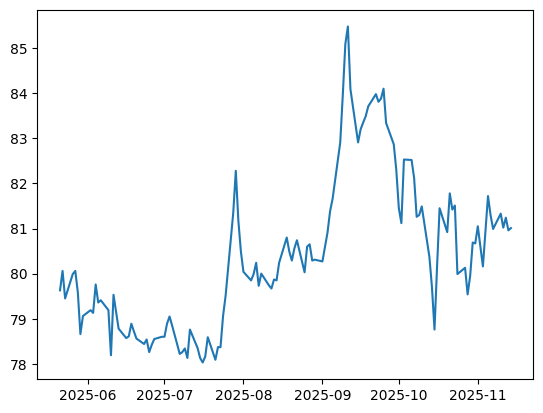

In [17]:
await draw_currency_diagram(
    usdrubf, datetime.now() - timedelta(days=180), datetime.now()
)

In [18]:
eurrubf = Asset(
    engine=Engines.FUTURES,
    market=Markets.FORTS,
    board=Boards.RFUD,
    # Однодневный фьючерсный контракт с автопролонгацией на курс евро - российский рубль
    ticker="EURRUBF",
)
display(
    await eurrubf.get_candles(
        start_date=datetime.now() - timedelta(days=180),
        end_date=datetime.now(),
        interval=IntervalEnum.DAY,
    )
)

,begin,open,close,high,low,value,volume,ticker
0,2025-05-21,91.29,90.66,91.90,90.36,0,12192,EURRUBF
1,2025-05-22,90.59,90.36,90.70,89.64,0,6922,EURRUBF
2,2025-05-23,90.48,90.15,91.17,90.00,0,3917,EURRUBF
3,2025-05-26,90.20,91.07,91.27,90.16,0,3707,EURRUBF
4,2025-05-27,91.08,90.93,91.43,90.71,0,7857,EURRUBF
...,...,...,...,...,...,...,...,...
122,2025-11-10,93.74,93.88,94.45,93.44,0,4430,EURRUBF
123,2025-11-11,93.90,93.96,94.70,93.75,0,4376,EURRUBF
124,2025-11-12,93.95,94.03,94.31,93.63,0,3687,EURRUBF
125,2025-11-13,94.12,94.19,94.27,93.26,0,9531,EURRUBF


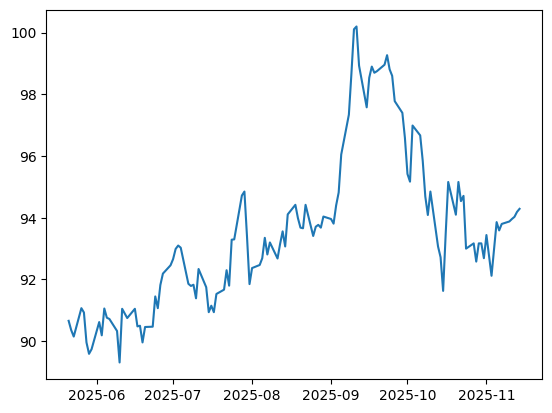

In [19]:
await draw_currency_diagram(
    eurrubf, datetime.now() - timedelta(days=180), datetime.now()
)

In [20]:
gldrubf = Asset(
    engine=Engines.FUTURES,
    market=Markets.FORTS,
    board=Boards.RFUD,
    # Однодневный фьючерсный контракт с автопролонгацией на золото
    ticker="GLDRUBF",
)
display(
    await gldrubf.get_candles(
        start_date=datetime.now() - timedelta(days=180),
        end_date=datetime.now(),
        interval=IntervalEnum.DAY,
    )
)

,begin,open,close,high,low,value,volume,ticker
0,2025-05-21,8509.2,8485.0,8600.0,8441.1,0,832183,GLDRUBF
1,2025-05-22,8527.0,8480.0,8549.9,8377.0,0,462978,GLDRUBF
2,2025-05-23,8474.0,8532.0,8580.0,8445.0,0,467257,GLDRUBF
3,2025-05-26,8535.0,8524.6,8555.0,8486.0,0,238832,GLDRUBF
4,2025-05-27,8528.0,8425.6,8534.9,8413.7,0,355543,GLDRUBF
...,...,...,...,...,...,...,...,...
124,2025-11-10,10348.9,10623.8,10689.0,10340.0,0,584667,GLDRUBF
125,2025-11-11,10636.4,10660.0,10819.8,10627.5,0,495194,GLDRUBF
126,2025-11-12,10660.0,10834.8,10860.3,10641.4,0,517128,GLDRUBF
127,2025-11-13,10856.3,10883.0,10978.2,10825.0,0,672647,GLDRUBF


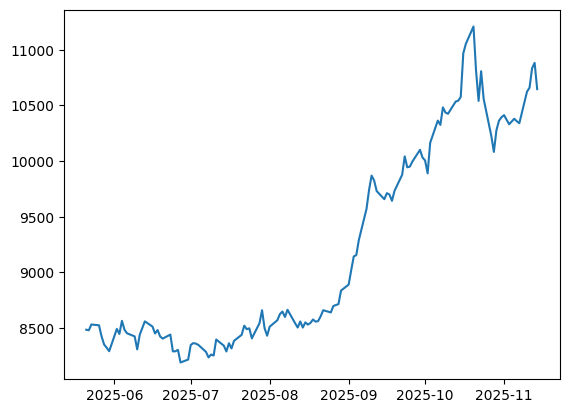

In [21]:
await draw_currency_diagram(
    gldrubf, datetime.now() - timedelta(days=180), datetime.now()
)

## Фьючерсы на нефть Brent

Список всех фьючерсов: https://iss.moex.com/iss/engines/futures/markets/forts/boards/RFUD/securities

### Расшифровка тикера фьючерса:

1. Название фьючерса:
- BR (10 баррелей)
- BRM (1 баррель)

По BR объемы выше, стоит взять его.

2. Месяц экспирации:

- Jan - F
- Feb - G
- Mar - H
- Apr - J
- May - K
- Jun - M
- Jul - N
- Aug - Q
- Sep - U
- Oct - V
- Nov - X
- Dec - Z

3. Год экспирации:

- 2022 - 2
- 2023 - 3
- 2024 - 4
- 2025 - 5
- 2026 - 6
- 2027 - 7
- etc.

Подробнее: https://www.moex.com/s205

### Особенности

1. Фьючерс на нефть Brent торгуется в USD.
2. Единовременно торгуются несколько фьючерсов, с разными месяцами экспирации.

### Предобработка

1. Берем последний доступный фьючерс, который торгуется в этот день.
2. Берем цену закрытия этого фьючерса.
3. Переводим USD в RUB по курсу доллара, который мы знаем из USDRUBF.

In [ ]:
# Пытаемся парсить
brf6 = Asset(
    engine=Engines.FUTURES,
    market=Markets.FORTS,
    board=Boards.RFUD,
    ticker="BRF6",
)
brg6 = Asset(
    engine=Engines.FUTURES,
    market=Markets.FORTS,
    board=Boards.RFUD,
    ticker="BRG6",
)
brh6 = Asset(
    engine=Engines.FUTURES,
    market=Markets.FORTS,
    board=Boards.RFUD,
    ticker="BRH6",
)
brx5 = Asset(
    engine=Engines.FUTURES,
    market=Markets.FORTS,
    board=Boards.RFUD,
    ticker="BRX5",
)
brz6 = Asset(
    engine=Engines.FUTURES,
    market=Markets.FORTS,
    board=Boards.RFUD,
    ticker="BRZ5",
)
print("brf6")
display(
    await brf6.get_candles(
        start_date=datetime.now() - timedelta(days=3),
        end_date=datetime.now(),
        interval=IntervalEnum.DAY,
    )
)
print("brg6")
display(
    await brg6.get_candles(
        start_date=datetime.now() - timedelta(days=3),
        end_date=datetime.now(),
        interval=IntervalEnum.DAY,
    )
)
print("brh6")
display(
    await brh6.get_candles(
        start_date=datetime.now() - timedelta(days=2),
        end_date=datetime.now(),
        interval=IntervalEnum.DAY,
    )
)
print("brz6")
display(
    await brz6.get_candles(
        start_date=datetime.now() - timedelta(days=2),
        end_date=datetime.now(),
        interval=IntervalEnum.DAY,
    )
)

# По тикерам BRJ6, BRK6, BRM6, BRX5 данных нет
# brx5 = Asset(
#     engine=Engines.FUTURES,
#     market=Markets.FORTS,
#     board=Boards.RFUD,
#     ticker="BRX5",
# )
# brj6 = Asset(
#     engine=Engines.FUTURES,
#     market=Markets.FORTS,
#     board=Boards.RFUD,
#     ticker='BRJ6',
# )
# brk6 = Asset(
#     engine=Engines.FUTURES,
#     market=Markets.FORTS,
#     board=Boards.RFUD,
#     ticker='BRK6',
# )
# brm6 = Asset(
#     engine=Engines.FUTURES,
#     market=Markets.FORTS,
#     board=Boards.RFUD,
#     ticker='BRM6',
# )

brf6


,begin,open,close,high,low,value,volume,ticker
0,2025-11-14,62.72,63.97,64.08,62.46,0,17175,BRF6


brg6


,begin,open,close,high,low,value,volume,ticker
0,2025-11-14,62.56,63.54,63.64,62.25,0,1871,BRG6


brh6


""


brz6


""


In [137]:
# Load data

def generate_all_brent_tickers(start_year=2022, end_year=2026):
    month_codes = {
        1: 'F', 2: 'G', 3: 'H', 4: 'J', 5: 'K', 6: 'M',
        7: 'N', 8: 'Q', 9: 'U', 10: 'V', 11: 'X', 12: 'Z'
    }
    year_codes = {2022: '2', 2023: '3', 2024: '4', 2025: '5', 2026: '6', 2027: '7'}
    
    tickers = []
    for year in range(start_year, end_year + 1):
        for month in range(1, 13):
            ticker = f"BR{month_codes[month]}{year_codes[year]}"
            expiry_date = pd.Timestamp(year=year, month=month, day=1)
            tickers.append({'ticker': ticker, 'expiry': expiry_date})
    
    return pd.DataFrame(tickers)


async def get_brent_futures_metadata():
    url = "https://iss.moex.com/iss/engines/futures/markets/forts/boards/RFUD/securities.json"
    async with aiohttp.ClientSession() as session:
        async with session.get(url) as response:
            data = await response.json()
    
    securities = data['securities']
    df_active = pd.DataFrame(securities['data'], columns=securities['columns'])
    df_active = df_active[df_active['SECID'].str.startswith('BR') & ~df_active['SECID'].str.startswith('BRM')]
    df_active['LASTTRADEDATE'] = pd.to_datetime(df_active['LASTTRADEDATE'])
    df_active = df_active[['SECID', 'LASTTRADEDATE']].rename(columns={'SECID': 'ticker', 'LASTTRADEDATE': 'expiry'})
    df_active = df_active.dropna()
    
    df_all = generate_all_brent_tickers(2022, 2027)
    
    for idx, row in df_active.iterrows():
        mask = df_all['ticker'] == row['ticker']
        if mask.any():
            df_all.loc[mask, 'expiry'] = row['expiry']
    
    return df_all.sort_values('expiry').reset_index(drop=True)

In [138]:
start_date = date(2022, 5, 31)
end_date = datetime.now()
interval = IntervalEnum.HOUR

print("Fetching Brent futures metadata...")
futures_meta = await get_brent_futures_metadata()
print(f"Found {len(futures_meta)} contracts")

print(f"\nFetching price data ({interval.name})...")
all_data = {}
for _, row in futures_meta.iterrows():
    ticker = row['ticker']
    asset = Asset(Engines.FUTURES, Markets.FORTS, Boards.RFUD, ticker)
    try:
        df = await asset.get_candles(start_date, min(end_date, row['expiry']), interval)
        if not df.empty:
            all_data[ticker] = df
            print(f"  {ticker}: {len(df)} rows (from {df['begin'].min().date()} to {df['begin'].max().date()})")
    except Exception as e:
        print(f"  {ticker}: ERROR - {e}")

Fetching Brent futures metadata...
Found 72 contracts

Fetching price data (HOUR)...
  BRM2: 9 rows (from 2022-05-31 to 2022-05-31)
  BRN2: 198 rows (from 2022-05-31 to 2022-06-30)
  BRQ2: 457 rows (from 2022-05-31 to 2022-07-29)
  BRU2: 779 rows (from 2022-05-31 to 2022-08-31)
  BRV2: 1016 rows (from 2022-05-31 to 2022-09-30)
  BRX2: 1205 rows (from 2022-05-31 to 2022-10-31)
  BRZ2: 1563 rows (from 2022-05-31 to 2022-11-30)
  BRF3: 1411 rows (from 2022-05-31 to 2022-12-30)
  BRG3: 1364 rows (from 2022-05-31 to 2023-01-31)
  BRH3: 1461 rows (from 2022-05-31 to 2023-02-28)
  BRJ3: 1368 rows (from 2022-06-03 to 2023-03-31)
  BRK3: 1457 rows (from 2022-06-02 to 2023-04-28)
  BRM3: 1556 rows (from 2022-06-03 to 2023-05-31)
  BRN3: 1601 rows (from 2022-06-29 to 2023-06-30)
  BRQ3: 1560 rows (from 2022-07-26 to 2023-07-31)
  BRU3: 1732 rows (from 2022-08-30 to 2023-08-31)
  BRV3: 1651 rows (from 2022-10-03 to 2023-09-29)
  BRX3: 1762 rows (from 2022-10-26 to 2023-10-31)
  BRZ3: 2074 rows (fr

In [139]:
import pandas as pd
from datetime import timedelta

def count_trading_days(start_date, end_date):
    if pd.isna(start_date) or pd.isna(end_date):
        return 0
    if isinstance(start_date, pd.Timestamp):
        start_date = start_date.date()
    if isinstance(end_date, pd.Timestamp):
        end_date = end_date.date()
    
    trading_days = 0
    current = start_date
    while current < end_date:
        if current.weekday() < 5:
            trading_days += 1
        current += timedelta(days=1)
    return trading_days


def select_contract(timestamp_t, futures_meta, all_data, roll_window=5):
    """
    Select the nearest-expiring futures contract for a given timestamp,
    subject to a minimum roll window in trading days.

    Parameters
    ----------
    timestamp_t : datetime-like
        The timestamp at which we want a contract (e.g. bar time).
    futures_meta : pd.DataFrame
        Must contain columns:
            - 'ticker' : str
            - 'expiry' : datetime64[ns] or convertible to datetime
        One row per contract.
    all_data : dict[str, pd.DataFrame]
        Mapping from ticker -> DataFrame with at least:
            - 'begin' : datetime64[ns] (bar start time)
    roll_window : int
        Minimum number of trading days to expiry to allow using this contract.

    Returns
    -------
    str | None
        Selected contract ticker, or None if no suitable contract has data
        at the given timestamp.
    """

    # Normalize timestamp
    timestamp_t = pd.Timestamp(timestamp_t)

    # Work in date space for roll logic
    date_t = timestamp_t.date()
    # Don't include contracts that expire more than 3 months from now
    date_t_max = date_t + timedelta(days=90)

    # Ensure expiry is proper datetime64[ns]
    futures_meta = futures_meta.copy()
    futures_meta['expiry'] = pd.to_datetime(futures_meta['expiry'])

    # Convert date_t and date_t_max to Timestamp so types match expiry (datetime64[ns])
    start_ts = pd.to_datetime(date_t)       # midnight of current date
    end_ts = pd.to_datetime(date_t_max)     # midnight of max date

    # Contracts whose expiry is strictly after current date and before date_t_max
    available = futures_meta.loc[
        (futures_meta['expiry'] > start_ts) &
        (futures_meta['expiry'] < end_ts)
    ].copy()

    if available.empty:
        return None

    # Compute days to expiry for each contract using trading days
    # Here we go back to pure `date` for count_trading_days
    available['days_to_expiry'] = available['expiry'].dt.date.apply(
        lambda d: count_trading_days(date_t, d)
    )

    # Keep only contracts that satisfy the roll_window constraint
    candidates = available.loc[available['days_to_expiry'] >= roll_window]
    if candidates.empty:
        return None

    # Sort so the nearest expiry (smallest days_to_expiry) is considered first
    candidates = candidates.sort_values(['days_to_expiry', 'expiry'])

    def has_bar_at_timestamp(ticker: str) -> bool:
        """Check that the given contract has data at timestamp_t."""
        df = all_data.get(ticker)
        if df is None or df.empty:
            return False
        return not df.loc[df['begin'] == timestamp_t].empty

    # Choose the nearest-expiring candidate that actually has a bar at this time
    for ticker in candidates['ticker']:
        if has_bar_at_timestamp(ticker):
            return ticker

    # No candidate contract had data at this timestamp
    return None



async def build_brent_continuous(start_date, end_date, all_data, futures_meta, roll_window=5):
    print(f"\nBuilding continuous series (roll_window={roll_window})...")
    all_timestamps = pd.date_range(start=start_date, end=end_date, freq='H')
    trading_timestamps = [ts for ts in all_timestamps if ts.weekday() < 5]
    
    rows = []
    missing_data_count = 0
    
    for timestamp_t in trading_timestamps:
        ticker = select_contract(timestamp_t, futures_meta, all_data, roll_window)
        
        if ticker:
            contract_data = all_data[ticker]
            ts_data = contract_data[contract_data['begin'] == timestamp_t]
            row = ts_data.iloc[0]
            expiry = futures_meta[futures_meta['ticker'] == ticker]['expiry'].iloc[0]
            rows.append({
                'begin': timestamp_t,
                'open': row['open'],
                'high': row['high'],
                'low': row['low'],
                'close': row['close'],
                'volume': row['volume'],
                'value': row['value'],
                'ticker': ticker,
                'expiry': expiry,
                'days_to_expiry': count_trading_days(timestamp_t.date(), expiry.date())
            })
        else:
            missing_data_count += 1
    
    df = pd.DataFrame(rows)
    print(f"\n✓ Generated {len(df)} data points from {df['begin'].min()} to {df['begin'].max()}")
    if missing_data_count > 0:
        print(f"⚠ Missing {missing_data_count} timestamps (no contract had data)")
    return df


start_date = date(2022, 5, 31)
end_date = datetime.now()

brent_continuous = await build_brent_continuous(start_date, end_date, all_data, futures_meta, roll_window=5)

brent_continuous_csv = brent_continuous.copy()
brent_continuous_csv['begin'] = brent_continuous_csv['begin'].dt.strftime("%Y-%m-%d %H:%M:%S")
brent_continuous_csv['expiry'] = brent_continuous_csv['expiry'].dt.strftime("%Y-%m-%d")
brent_continuous_csv.to_csv('data/brent_continuous.csv', index=False)

print(f"\n✓ Saved to data/brent_continuous.csv")
print(f"Total rows: {len(brent_continuous)}")
print(f"Date range: {brent_continuous['begin'].min()} to {brent_continuous['begin'].max()}")
print(f"Unique contracts used: {brent_continuous['ticker'].nunique()}")
display(brent_continuous.head(10))
display(brent_continuous.tail(10))



Building continuous series (roll_window=5)...


/tmp/ipykernel_1073431/247930874.py:106: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  all_timestamps = pd.date_range(start=start_date, end=end_date, freq='H')



✓ Generated 13376 data points from 2022-05-31 10:00:00 to 2025-11-14 23:00:00
⚠ Missing 8320 timestamps (no contract had data)

✓ Saved to data/brent_continuous.csv
Total rows: 13376
Date range: 2022-05-31 10:00:00 to 2025-11-14 23:00:00
Unique contracts used: 42


,begin,open,high,low,close,volume,value,ticker,expiry,days_to_expiry
0,2022-05-31 10:00:00,117.55,119.77,117.55,119.29,7757,0,BRN2,2022-07-01,23
1,2022-05-31 11:00:00,119.29,119.67,118.98,119.14,5844,0,BRN2,2022-07-01,23
2,2022-05-31 12:00:00,119.14,119.19,118.67,119.15,3682,0,BRN2,2022-07-01,23
3,2022-05-31 13:00:00,119.16,119.55,118.94,119.31,4678,0,BRN2,2022-07-01,23
4,2022-05-31 14:00:00,119.31,119.52,119.02,119.02,3570,0,BRN2,2022-07-01,23
5,2022-05-31 15:00:00,119.05,119.52,118.70,119.46,3159,0,BRN2,2022-07-01,23
6,2022-05-31 16:00:00,119.45,120.30,118.93,119.37,6733,0,BRN2,2022-07-01,23
7,2022-05-31 17:00:00,119.38,119.43,118.39,118.62,6363,0,BRN2,2022-07-01,23
8,2022-05-31 18:00:00,118.58,118.62,117.10,118.49,7508,0,BRN2,2022-07-01,23
9,2022-06-01 10:00:00,117.09,118.37,116.07,117.93,10193,0,BRN2,2022-07-01,22


,begin,open,high,low,close,volume,value,ticker,expiry,days_to_expiry
13366,2025-11-14 14:00:00,64.60,64.60,63.63,63.83,47636,0,BRZ5,2025-12-01,11
13367,2025-11-14 15:00:00,63.83,64.05,63.75,63.77,23100,0,BRZ5,2025-12-01,11
13368,2025-11-14 16:00:00,63.79,64.10,63.71,64.00,25013,0,BRZ5,2025-12-01,11
13369,2025-11-14 17:00:00,63.98,64.28,63.91,64.24,18978,0,BRZ5,2025-12-01,11
13370,2025-11-14 18:00:00,64.24,64.52,64.14,64.49,14556,0,BRZ5,2025-12-01,11
13371,2025-11-14 19:00:00,64.43,64.66,64.34,64.42,22184,0,BRZ5,2025-12-01,11
13372,2025-11-14 20:00:00,64.41,64.52,64.31,64.44,11283,0,BRZ5,2025-12-01,11
13373,2025-11-14 21:00:00,64.44,64.49,64.30,64.36,7685,0,BRZ5,2025-12-01,11
13374,2025-11-14 22:00:00,64.35,64.39,64.25,64.38,17872,0,BRZ5,2025-12-01,11
13375,2025-11-14 23:00:00,64.38,64.38,64.20,64.30,8206,0,BRZ5,2025-12-01,11


In [106]:
# Load eia prices
eia_prices = pd.read_csv('data/brent_eia.csv')
eia_prices['begin'] = pd.to_datetime(eia_prices['begin'])


### Сравниваем данные из EIA с Brent фьючерсами MOEX

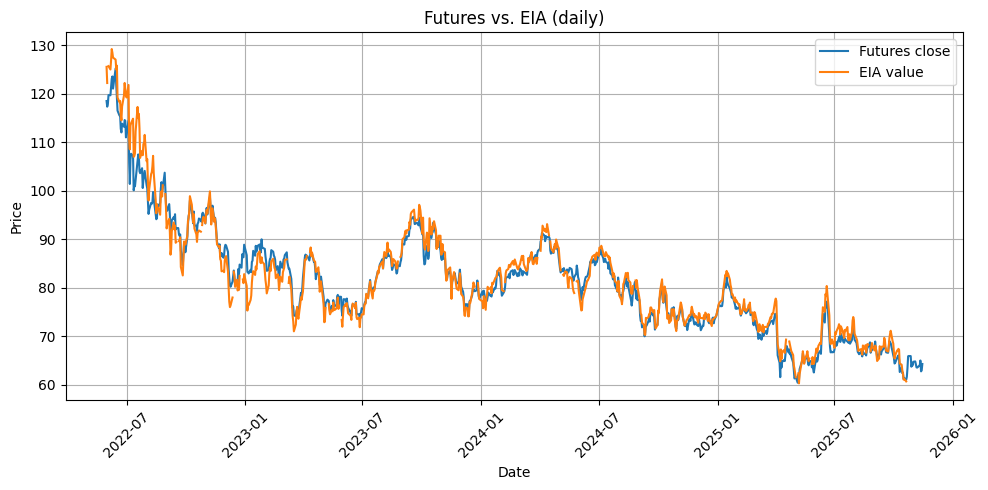

In [140]:
# First dataframe: intraday futures data
# Columns: begin,open,high,low,close,volume,value,ticker,expiry,days_to_expiry
brent_continuous['begin'] = pd.to_datetime(brent_continuous['begin'])

# Second dataframe: daily (or interval) data for another ticker
# Columns (at minimum): value,begin,end,ticker (plus possible index column)
eia_prices['begin'] = pd.to_datetime(eia_prices['begin'])

# --- 2. Aggregate first dataframe by day ---

# Create "date" column (midnight-normalized date for grouping)
brent_continuous['date'] = brent_continuous['begin'].dt.normalize()

# Aggregate intraday rows into daily OHLCV (+ some metadata)
brent_continuous_daily = (
    brent_continuous
    .groupby('date', as_index=False)
    .agg({
        'open': 'first',          # first open of the day
        'high': 'max',            # daily high
        'low': 'min',             # daily low
        'close': 'last',          # last close of the day
        'volume': 'sum',          # total volume
        'value': 'sum',           # sum of "value" over the day (change if you need mean)
        'ticker': 'first',        # ticker (assuming same for the group)
        'expiry': 'first',        # expiry (assuming same for the group)
        'days_to_expiry': 'first' # days_to_expiry (assuming same for the group)
    })
)

# --- 3. Prepare second dataframe as daily data ---

# If eia_prices is already one row per day, this will simply add a "date" column.
# If not, this will aggregate multiple rows within a day.
eia_prices['date'] = eia_prices['begin'].dt.normalize()

eia_prices_daily = (
    eia_prices
    .groupby('date', as_index=False)
    .agg({
        'value': 'mean',    # average value during the day (change to 'last'/'first' if needed)
        'ticker': 'first'   # keep the ticker label (e.g. RBRTE)
    })
)

# Rename eia_prices value column so we can distinguish it after merge
eia_prices_daily = eia_prices_daily.rename(columns={'value': 'rbrte_value'})

# --- 4. Merge both daily datasets on date ---

merged = pd.merge(
    brent_continuous_daily,
    eia_prices_daily[['date', 'rbrte_value']],
    on='date',
    how='left'
)

# --- 5. Plot both series ---

plt.figure(figsize=(10, 5))

# Plot futures close price (from first dataframe)
plt.plot(merged['date'], merged['close'], label='Futures close')

# Plot spot (or whatever "value" is) from second dataframe
plt.plot(merged['date'], merged['rbrte_value'], label='EIA value')

plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Futures vs. EIA (daily)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(True)

plt.show()

### Сравнение фьючерса на золото и спотового золота

In [23]:
# Сравним GLDRUB_TOM и GLDRUBF

df_gold = await gold.get_candles(
    start_date=datetime.now() - timedelta(days=180),
    end_date=datetime.now(),
    interval=IntervalEnum.HOUR,
)
df_gold_future = await gldrubf.get_candles(
    start_date=datetime.now() - timedelta(days=180),
    end_date=datetime.now(),
    interval=IntervalEnum.HOUR,
)
display(df_gold[:5])
display(df_gold_future[:5])

,begin,open,close,high,low,value,volume,ticker
0,2025-05-20 09:00:00,8325.0,8325.0,8325.0,8325.0,2497500.0,300,GLDRUB_TOM
1,2025-05-20 10:00:00,8321.0,8394.6,8400.0,8311.1,124455585.2,14892,GLDRUB_TOM
2,2025-05-20 11:00:00,8396.8,8404.2,8411.1,8364.1,731613571.1,87222,GLDRUB_TOM
3,2025-05-20 12:00:00,8404.3,8410.0,8417.5,8390.0,220053820.8,26174,GLDRUB_TOM
4,2025-05-20 13:00:00,8410.0,8424.3,8430.9,8403.2,543761754.8,64589,GLDRUB_TOM


,begin,open,close,high,low,value,volume,ticker
0,2025-05-20 08:00:00,8354.9,8354.9,8354.9,8354.9,0,1180,GLDRUBF
1,2025-05-20 09:00:00,8353.3,8329.2,8359.1,8321.1,0,21658,GLDRUBF
2,2025-05-20 10:00:00,8329.0,8403.6,8415.5,8326.3,0,51137,GLDRUBF
3,2025-05-20 11:00:00,8403.8,8418.3,8419.8,8375.2,0,87181,GLDRUBF
4,2025-05-20 12:00:00,8418.3,8425.2,8431.7,8400.5,0,38914,GLDRUBF


In [24]:
print(f"GLDRUB_TOM dimensions: {df_gold.shape}")
print(f"GLDRUBF dimensions: {df_gold_future.shape}")

print(
    f"GLDRUB_TOM min/avg/max value: {df_gold['value'].min()}/{df_gold['value'].mean():.2f}/{df_gold['value'].max()}"
)
print(
    f"GLDRUBF min/avg/max value: {df_gold_future['value'].min()}/{df_gold_future['value'].mean():.2f}/{df_gold_future['value'].max()}"
)

print(
    f"GLDRUB_TOM open min/avg/max: {df_gold['open'].min()}/{df_gold['open'].mean():.2f}/{df_gold['open'].max()}"
)
print(
    f"GLDRUBF open min/avg/max: {df_gold_future['open'].min()}/{df_gold_future['open'].mean():.2f}/{df_gold_future['open'].max()}"
)

print(
    f"GLDRUB_TOM high min/avg/max: {df_gold['high'].min()}/{df_gold['high'].mean():.2f}/{df_gold['high'].max()}"
)
print(
    f"GLDRUBF high min/avg/max: {df_gold_future['high'].min()}/{df_gold_future['high'].mean():.2f}/{df_gold_future['high'].max()}"
)

print(
    f"GLDRUB_TOM low min/avg/max: {df_gold['low'].min()}/{df_gold['low'].mean():.2f}/{df_gold['low'].max()}"
)
print(
    f"GLDRUBF low min/avg/max: {df_gold_future['low'].min()}/{df_gold_future['low'].mean():.2f}/{df_gold_future['low'].max()}"
)

print(
    f"GLDRUB_TOM close min/avg/max: {df_gold['close'].min()}/{df_gold['close'].mean():.2f}/{df_gold['close'].max()}"
)
print(
    f"GLDRUBF close min/avg/max: {df_gold_future['close'].min()}/{df_gold_future['close'].mean():.2f}/{df_gold_future['close'].max()}"
)

print(
    f"GLDRUB_TOM volume min/avg/max: {df_gold['volume'].min()}/{df_gold['volume'].mean():.2f}/{df_gold['volume'].max()}"
)
print(
    f"GLDRUBF volume min/avg/max: {df_gold_future['volume'].min()}/{df_gold_future['volume'].mean():.2f}/{df_gold_future['volume'].max()}"
)

print(f"GLDRUB_TOM date range: {df_gold['begin'].min()}/{df_gold['begin'].max()}")
print(
    f"GLDRUBF date range: {df_gold_future['begin'].min()}/{df_gold_future['begin'].max()}"
)


GLDRUB_TOM dimensions: (1280, 8)
GLDRUBF dimensions: (2246, 8)
GLDRUB_TOM min/avg/max value: 17144.0/385665398.08/3303037042.299999
GLDRUBF min/avg/max value: 0/0.00/0
GLDRUB_TOM open min/avg/max: 8175.0/9187.53/11300.0
GLDRUBF open min/avg/max: 8183.9/9250.71/11306.2
GLDRUB_TOM high min/avg/max: 8193.5/9204.67/11370.0
GLDRUBF high min/avg/max: 8198.8/9266.80/11377.4
GLDRUB_TOM low min/avg/max: 8165.0/9169.40/11288.2
GLDRUBF low min/avg/max: 8109.9/9234.28/11270.8
GLDRUB_TOM close min/avg/max: 8175.0/9187.56/11288.2
GLDRUBF close min/avg/max: 8184.2/9251.22/11305.6
GLDRUB_TOM volume min/avg/max: 2/41263.61/343971
GLDRUBF volume min/avg/max: 1/27907.76/366704
GLDRUB_TOM date range: 2025-05-20 09:00:00/2025-11-14 18:00:00
GLDRUBF date range: 2025-05-20 08:00:00/2025-11-15 18:00:00


In [25]:
# Нарисуем график времени торгов за прошедший месяц
from matplotlib import pyplot as plt
import matplotlib.dates as mdates

df_gold_last_month = df_gold[
    df_gold["begin"] >= datetime.fromisoformat("2025-10-01")
].copy()
df_gold_future_last_month = df_gold_future[
    df_gold_future["begin"] >= datetime.fromisoformat("2025-10-01")
].copy()

df_gold_last_month_grouped = (
    df_gold_last_month.groupby(df_gold_last_month["begin"].dt.date.rename("date"))
    .agg({"begin": ["min", "max"]})
    .reset_index()
)
df_gold_last_month_grouped.columns = [
    "date",
    "begin_min",
    "begin_max",
]
df_gold_last_month_grouped["date"] = pd.to_datetime(df_gold_last_month_grouped["date"])
for col in ["begin_min", "begin_max"]:
    df_gold_last_month_grouped[col] = pd.to_datetime(
        df_gold_last_month_grouped[col]
    ).dt.time
df_gold_last_month_grouped["begin_min"] = df_gold_last_month_grouped["begin_min"].apply(
    lambda t: datetime.combine(datetime.min, t)
)
df_gold_last_month_grouped["begin_max"] = df_gold_last_month_grouped["begin_max"].apply(
    lambda t: datetime.combine(datetime.min, t)
)

display(df_gold_last_month_grouped[:5])

df_gold_future_last_month_grouped = (
    df_gold_future_last_month.groupby(
        df_gold_future_last_month["begin"].dt.date.rename("date")
    )
    .agg({"begin": ["min", "max"]})
    .reset_index()
)
df_gold_future_last_month_grouped.columns = [
    "date",
    "begin_min",
    "begin_max",
]
df_gold_future_last_month_grouped["date"] = pd.to_datetime(
    df_gold_future_last_month_grouped["date"]
)
for col in ["begin_min", "begin_max"]:
    df_gold_future_last_month_grouped[col] = pd.to_datetime(
        df_gold_future_last_month_grouped[col]
    ).dt.time
df_gold_future_last_month_grouped["begin_min"] = df_gold_future_last_month_grouped[
    "begin_min"
].apply(lambda t: datetime.combine(datetime.min, t))
df_gold_future_last_month_grouped["begin_max"] = df_gold_future_last_month_grouped[
    "begin_max"
].apply(lambda t: datetime.combine(datetime.min, t))

display(df_gold_future_last_month_grouped[:5])


,date,begin_min,begin_max
0,2025-10-01,0001-01-01 09:00:00,0001-01-01 18:00:00
1,2025-10-02,0001-01-01 09:00:00,0001-01-01 18:00:00
2,2025-10-03,0001-01-01 09:00:00,0001-01-01 18:00:00
3,2025-10-06,0001-01-01 09:00:00,0001-01-01 18:00:00
4,2025-10-07,0001-01-01 09:00:00,0001-01-01 18:00:00


,date,begin_min,begin_max
0,2025-10-01,0001-01-01 08:00:00,0001-01-01 23:00:00
1,2025-10-02,0001-01-01 08:00:00,0001-01-01 23:00:00
2,2025-10-03,0001-01-01 08:00:00,0001-01-01 23:00:00
3,2025-10-04,0001-01-01 09:00:00,0001-01-01 18:00:00
4,2025-10-05,0001-01-01 09:00:00,0001-01-01 18:00:00


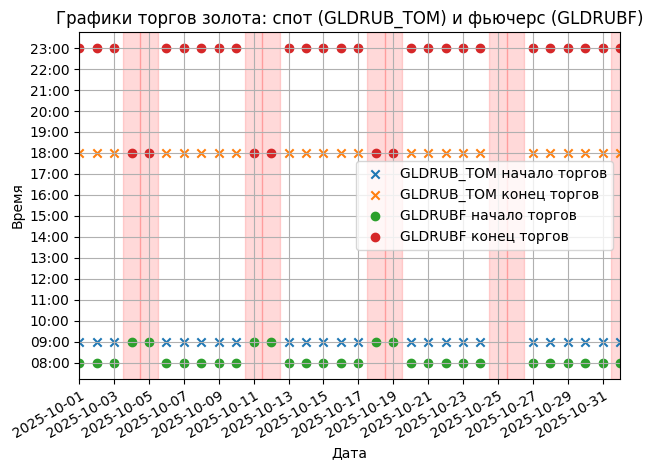

In [26]:
fig, ax = plt.subplots()

# Highlight weekends
start = pd.Timestamp("2025-10-01")
end_exclusive = pd.Timestamp("2025-11-01")
for day in pd.date_range(start, end_exclusive, freq="D"):
    if day.weekday() >= 5:  # 5=Sat, 6=Sun
        ax.axvspan(
            day - pd.Timedelta(hours=12),
            day + pd.Timedelta(hours=12),
            color="red",
            alpha=0.15,
            zorder=-1,
        )

ax.scatter(
    df_gold_last_month_grouped["date"],
    df_gold_last_month_grouped["begin_min"],
    marker="x",
    label="GLDRUB_TOM начало торгов",
)
ax.scatter(
    df_gold_last_month_grouped["date"],
    df_gold_last_month_grouped["begin_max"],
    marker="x",
    label="GLDRUB_TOM конец торгов",
)
ax.scatter(
    df_gold_future_last_month_grouped["date"],
    df_gold_future_last_month_grouped["begin_min"],
    marker="o",
    label="GLDRUBF начало торгов",
)
ax.scatter(
    df_gold_future_last_month_grouped["date"],
    df_gold_future_last_month_grouped["begin_max"],
    marker="o",
    label="GLDRUBF конец торгов",
)

# Set NaN for every missing day
df_gold_last_month_grouped["begin_min"] = df_gold_last_month_grouped[
    "begin_min"
].fillna(pd.NaT)
df_gold_last_month_grouped["begin_max"] = df_gold_last_month_grouped[
    "begin_max"
].fillna(pd.NaT)

# Format X axis (dates)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))

# Format Y axis (times)
ax.yaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.yaxis.set_major_locator(mdates.HourLocator(interval=1))

ax.set_xlim(start, end_exclusive)

for label in ax.get_xticklabels():
    label.set_ha("right")
    label.set_x(-0.05)
    label.set_rotation_mode("anchor")

plt.xticks(rotation=30)
plt.xlabel("Дата")
plt.ylabel("Время")
plt.title("Графики торгов золота: спот (GLDRUB_TOM) и фьючерс (GLDRUBF)")
plt.grid()
plt.legend(loc="right")
plt.tight_layout()
plt.show()

Вывод:
- Торги на споте мосбиржи начинаются в 9:00 и заканчиваются в 18:00. Торги проводятся только в будни.
- Торги фьючерсами проводятся каждый день. В будни (основная сессия + вечерняя сессия) торги начинаются в 8:00 и заканчиваются в 00:00. В выходные (дополнительная сессия выходного дня) торги начинаются в 9:00 и заканчиваются в 19:00.

25-26 октября были тех. работы, поэтому торги не проводились: https://www.moex.com/n94725

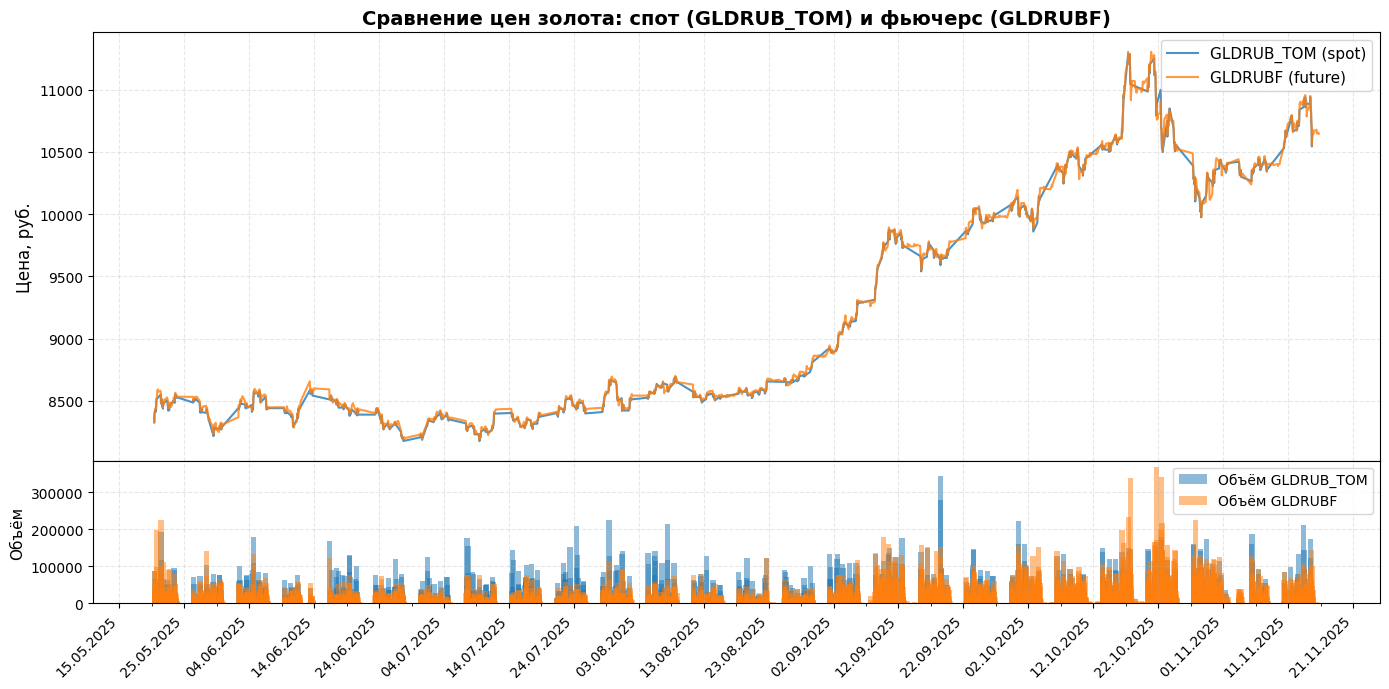

In [27]:
from matplotlib import pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

df_gold["begin"] = pd.to_datetime(df_gold["begin"])
df_gold_future["begin"] = pd.to_datetime(df_gold_future["begin"])

df_gold_sorted = df_gold.sort_values("begin")
df_gold_future_sorted = df_gold_future.sort_values("begin")

fig = plt.figure(figsize=(14, 7))
gs = fig.add_gridspec(2, 1, height_ratios=[3, 1], hspace=0)

# ---- PRICE AXIS ----
ax_price = fig.add_subplot(gs[0])

ax_price.plot(
    df_gold_sorted["begin"],
    df_gold_sorted["close"],
    label="GLDRUB_TOM (spot)",
    alpha=0.8,
    linewidth=1.5,
)

ax_price.plot(
    df_gold_future_sorted["begin"],
    df_gold_future_sorted["close"],
    label="GLDRUBF (future)",
    alpha=0.8,
    linewidth=1.5,
)

ax_price.set_ylabel("Цена, руб.", fontsize=12)
ax_price.set_title(
    "Сравнение цен золота: спот (GLDRUB_TOM) и фьючерс (GLDRUBF)",
    fontsize=14,
    fontweight="bold",
)
ax_price.legend(loc="best", fontsize=11)
ax_price.grid(True, alpha=0.3, linestyle="--")

# ---- VOLUME AXIS ----
ax_vol = fig.add_subplot(gs[1], sharex=ax_price)

# Spot volume (blue)
ax_vol.bar(
    df_gold_sorted["begin"],
    df_gold_sorted["volume"],
    width=0.8,
    alpha=0.5,
    label="Объём GLDRUB_TOM",
)

# Future volume (orange)
ax_vol.bar(
    df_gold_future_sorted["begin"],
    df_gold_future_sorted["volume"],
    width=0.8,
    alpha=0.5,
    label="Объём GLDRUBF",
)

ax_vol.set_ylabel("Объём", fontsize=11)
ax_vol.grid(True, alpha=0.3, linestyle="--")
ax_vol.legend(loc="best", fontsize=10)

# ---- X axis formatting ----
ax_vol.xaxis.set_major_locator(mdates.DayLocator(interval=10))
ax_vol.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m.%Y"))
ax_vol.xaxis.set_minor_locator(mdates.DayLocator(interval=5))
plt.setp(ax_price.get_xticklabels(), visible=False)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


Вывод:
- цены на спот золото и на фьючерс по золоту не сильно отличаются.
- фьючерс торгуется каждый день, даже в выходные, поэтому он может быть удобен для технического анализа.
- во фьючерсе меньше средний объем торгов, чем на споте. Однако за последний месяц объем торгов во фьючерсе выше, чем на споте, в связи с ростом интереса к золоту.

## Итог
- Удалось спарсить с мосбиржи данные по доллару, евро, юаню, золоту (и другим драгметаллам), нефти.
- Доллар, евро и нефть не торгуются на мосбирже, поэтому для анализа лучше использовать фьючерсы.
- Для анализа золота может подойти как фьючерс, так и спот. Стоимость фьючерса отличается от спота, но фьючерс торгуется в вечернюю и выходные сессии. При анализе стоит выбрать наиболее подходящий актив.

In [142]:
# Готовые для парсинга активы

# Золото
gold = Asset(
    engine=Engines.CURRENCY,
    market=Markets.SELT,
    board=Boards.CETS,
    ticker="GLDRUB_TOM",
)

# Фьючерс на золото
gldrubf = Asset(
    engine=Engines.FUTURES,
    market=Markets.FORTS,
    board=Boards.RFUD,
    ticker="GLDRUBF",
)

# Фьючерс USD/RUB
usdrubf = Asset(
    engine=Engines.FUTURES,
    market=Markets.FORTS,
    board=Boards.RFUD,
    ticker="USDRUBF",
)

# Фьючерс EUR/RUB
eurrubf = Asset(
    engine=Engines.FUTURES,
    market=Markets.FORTS,
    board=Boards.RFUD,
    ticker="EURRUBF",
)

# Спот CNY/RUB
cnyrub = Asset(
    engine=Engines.CURRENCY,
    market=Markets.SELT,
    board=Boards.CETS,
    ticker="CNYRUB_TOM",
)

# Фьючерс CNY/RUB
cnyrubf = Asset(
    engine=Engines.FUTURES,
    market=Markets.FORTS,
    board=Boards.RFUD,
    ticker="CNYRUBF",
)

# Фьючерсы на нефть Brent
brf6 = Asset(
    engine=Engines.FUTURES,
    market=Markets.FORTS,
    board=Boards.RFUD,
    ticker="BRF6",
)
brg6 = Asset(
    engine=Engines.FUTURES,
    market=Markets.FORTS,
    board=Boards.RFUD,
    ticker="BRG6",
)
brh6 = Asset(
    engine=Engines.FUTURES,
    market=Markets.FORTS,
    board=Boards.RFUD,
    ticker="BRH6",
)
brz6 = Asset(
    engine=Engines.FUTURES,
    market=Markets.FORTS,
    board=Boards.RFUD,
    ticker="BRZ5",
)

for a in [gold, gldrubf, brf6, brg6, brh6, brz6, usdrubf, eurrubf, cnyrub, cnyrubf]:
    try:
        print(a.ticker)
        df = await a.get_candles(
            start_date=datetime.now() - timedelta(days=3),
            end_date=datetime.now(),
            interval=IntervalEnum.HOUR,
        )
        display(df[:3])
    except Exception as e:
        print(f"{a.ticker} error: {e}")


GLDRUB_TOM


,begin,open,close,high,low,value,volume,ticker
0,2025-11-13 09:00:00,10860.2,10860.2,10860.2,10860.2,1.246751e+07,1148,GLDRUB_TOM
1,2025-11-13 10:00:00,10863.9,10896.1,10903.0,10838.0,2.285552e+09,210094,GLDRUB_TOM
2,2025-11-13 11:00:00,10899.9,10908.0,10964.8,10896.0,1.567855e+09,143495,GLDRUB_TOM


GLDRUBF


,begin,open,close,high,low,value,volume,ticker
0,2025-11-13 08:00:00,10910.0,10910.0,10910.0,10910.0,0,306,GLDRUBF
1,2025-11-13 09:00:00,10910.0,10873.1,10919.7,10825.0,0,41699,GLDRUBF
2,2025-11-13 10:00:00,10873.2,10913.9,10918.0,10855.0,0,110043,GLDRUBF


BRF6


...

,begin,open,close,high,low,value,volume,ticker
0,2025-11-13 09:00:00,93.82,93.59,93.89,93.35,0,882,EURRUBF
1,2025-11-13 10:00:00,93.58,93.65,93.77,93.50,0,215,EURRUBF
2,2025-11-13 11:00:00,93.70,93.61,93.75,93.55,0,117,EURRUBF


CNYRUB_TOM


,begin,open,close,high,low,value,volume,ticker
0,2025-11-13 09:00:00,11.3320,11.332,11.3320,11.3320,6.742540e+06,595000,CNYRUB_TOM
1,2025-11-13 10:00:00,11.3305,11.336,11.3560,11.3170,2.522509e+10,2226172000,CNYRUB_TOM
2,2025-11-13 11:00:00,11.3375,11.306,11.3415,11.3045,1.518615e+10,1340828000,CNYRUB_TOM


CNYRUBF


,begin,open,close,high,low,value,volume,ticker
0,2025-11-13 08:00:00,11.373,11.373,11.373,11.373,0,21,CNYRUBF
1,2025-11-13 09:00:00,11.367,11.330,11.374,11.303,0,160781,CNYRUBF
2,2025-11-13 10:00:00,11.329,11.349,11.369,11.328,0,403496,CNYRUBF


# Parse and save into CSV

In [34]:
start = date(2022, 5, 31)
end = datetime.now()

In [ ]:
from datetime import time

def get_df_info(df):
    display(df.shape)
    # Min date
    display(df["begin"].min())
    # Max date
    display(df["begin"].max())
    # First 3 rows
    display(df.head(3))
    # Last 3 rows
    display(df.tail(3))

def filter_main_sessions(df):
    # Filter only main session on weekdays
    df = df[df["begin"].dt.weekday < 5]
    df = df[(df["begin"].dt.time >= time(9, 0)) & (df["begin"].dt.time <= time(18, 0))]
    return df

async def parse_n_save(a, f=False):
    df = await a.get_candles(
        start_date=start,
        end_date=end,
        interval=IntervalEnum.HOUR,
    )
    if f:
        df = filter_main_sessions(df)
    get_df_info(df)
    df.to_csv(f"data/{a.ticker}.csv", index=False)

In [ ]:
# Check which rows are being filtered out
df = await gold.get_candles(
    start_date=start,
    end_date=end,
    interval=IntervalEnum.HOUR,
)
display(df.shape)
new_df = filter_main_sessions(df)
display(new_df.shape)

# Subtract new_df from df
df_excluded = df[~df["begin"].isin(new_df["begin"])]
df_excluded.shape
# Dates print
dates_unique = df_excluded["begin"].dt.date.unique()
dates_unique.sort()
for d in dates_unique:
    print(d, d.weekday())


In [78]:
await parse_n_save(gold)

(8759, 8)

Timestamp('2022-05-31 09:00:00')

Timestamp('2025-11-14 18:00:00')

,begin,open,close,high,low,value,volume,ticker
0,2022-05-31 09:00:00,3645.6,3645.60,3645.6,3645.60,3.098760e+05,85,GLDRUB_TOM
1,2022-05-31 10:00:00,3650.0,3472.99,3650.0,3336.76,2.310602e+08,66962,GLDRUB_TOM
2,2022-05-31 11:00:00,3462.0,3478.00,3545.0,3409.99,7.834295e+07,22593,GLDRUB_TOM


,begin,open,close,high,low,value,volume,ticker
10109,2025-11-14 16:00:00,10708.8,10544.7,10716.6,10500.4,617404132.8,58432,GLDRUB_TOM
10110,2025-11-14 17:00:00,10541.1,10616.4,10616.4,10506.6,342806211.3,32484,GLDRUB_TOM
10111,2025-11-14 18:00:00,10614.3,10637.4,10637.4,10582.7,185306434.2,17469,GLDRUB_TOM


In [79]:
await parse_n_save(gldrubf)

(5972, 8)

Timestamp('2023-07-11 10:00:00')

Timestamp('2025-11-14 18:00:00')

,begin,open,close,high,low,value,volume,ticker
0,2023-07-11 10:00:00,5500.0,5504.2,5506.0,5479.0,0,519,GLDRUBF
1,2023-07-11 11:00:00,5506.4,5516.4,5520.5,5497.1,0,329,GLDRUBF
2,2023-07-11 12:00:00,5515.5,5503.4,5515.5,5491.6,0,469,GLDRUBF


,begin,open,close,high,low,value,volume,ticker
9568,2025-11-14 16:00:00,10715.4,10552.5,10728.8,10511.8,0,144393,GLDRUBF
9569,2025-11-14 17:00:00,10552.0,10620.4,10630.0,10511.2,0,101894,GLDRUBF
9570,2025-11-14 18:00:00,10620.1,10647.1,10649.6,10589.0,0,47310,GLDRUBF


In [80]:
await parse_n_save(usdrubf)

(8704, 8)

Timestamp('2022-05-31 10:00:00')

Timestamp('2025-11-14 18:00:00')

,begin,open,close,high,low,value,volume,ticker
0,2022-05-31 10:00:00,65.07,65.12,66.79,63.21,0,3811,USDRUBF
1,2022-05-31 11:00:00,65.11,64.36,65.40,64.30,0,1768,USDRUBF
2,2022-05-31 12:00:00,64.42,64.33,65.10,64.28,0,1343,USDRUBF


,begin,open,close,high,low,value,volume,ticker
13379,2025-11-14 16:00:00,81.18,81.05,81.24,81.00,0,8020,USDRUBF
13380,2025-11-14 17:00:00,81.04,81.06,81.18,81.01,0,17810,USDRUBF
13381,2025-11-14 18:00:00,81.07,81.01,81.14,81.01,0,22146,USDRUBF


In [81]:
await parse_n_save(eurrubf)

(8573, 8)

Timestamp('2022-05-31 10:00:00')

Timestamp('2025-11-14 18:00:00')

,begin,open,close,high,low,value,volume,ticker
0,2022-05-31 10:00:00,65.00,66.83,67.56,64.72,0,288,EURRUBF
1,2022-05-31 11:00:00,66.82,65.78,67.06,65.68,0,218,EURRUBF
2,2022-05-31 12:00:00,65.78,65.87,66.14,65.65,0,304,EURRUBF


,begin,open,close,high,low,value,volume,ticker
12832,2025-11-14 16:00:00,94.5,94.19,94.53,94.19,0,198,EURRUBF
12833,2025-11-14 17:00:00,94.2,94.30,94.41,94.19,0,2932,EURRUBF
12834,2025-11-14 18:00:00,94.3,94.29,94.41,94.24,0,3194,EURRUBF


In [87]:
await parse_n_save(cnyrub)

(8795, 8)

Timestamp('2022-05-31 09:00:00')

Timestamp('2025-11-14 18:00:00')

,begin,open,close,high,low,value,volume,ticker
0,2022-05-31 09:00:00,9.5390,9.5390,9.539,9.5390,2.470601e+06,259000,CNYRUB_TOM
1,2022-05-31 10:00:00,9.5390,9.4680,9.680,9.2000,3.897142e+09,412190000,CNYRUB_TOM
2,2022-05-31 11:00:00,9.4592,9.4075,9.494,9.3951,3.772170e+09,400097000,CNYRUB_TOM


,begin,open,close,high,low,value,volume,ticker
10150,2025-11-14 16:00:00,11.3945,11.3700,11.400,11.3690,4.296805e+09,377415000,CNYRUB_TOM
10151,2025-11-14 17:00:00,11.3700,11.3825,11.393,11.3685,3.751392e+09,329749000,CNYRUB_TOM
10152,2025-11-14 18:00:00,11.3820,11.3755,11.392,11.3715,1.559473e+09,137021000,CNYRUB_TOM


In [143]:
await parse_n_save(cnyrubf)

(8719, 8)

Timestamp('2022-05-31 10:00:00')

Timestamp('2025-11-14 18:00:00')

,begin,open,close,high,low,value,volume,ticker
0,2022-05-31 10:00:00,10.00,10.58,10.60,10.00,0,254,CNYRUBF
1,2022-05-31 11:00:00,10.58,10.46,10.58,10.46,0,100,CNYRUBF
2,2022-05-31 12:00:00,10.46,10.40,10.50,10.38,0,98,CNYRUBF


,begin,open,close,high,low,value,volume,ticker
13360,2025-11-14 16:00:00,11.404,11.380,11.411,11.378,0,84140,CNYRUBF
13361,2025-11-14 17:00:00,11.379,11.391,11.402,11.378,0,112168,CNYRUBF
13362,2025-11-14 18:00:00,11.392,11.386,11.403,11.383,0,93854,CNYRUBF
